In [189]:
# Complete Clean Inverse Model (CVAE-based) for Nanohole Array Design

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

In [190]:
# --- Step 1: Load and Preprocess Dataset ---
data = pd.read_csv("Dataset 6655.csv", header=None)

param_columns = ['Lattice', 'Material', 'Thickness', 'Radius', 'Periodicity']
spectrum_columns = [f'λ_{i}' for i in range(200)]
data.columns = param_columns + spectrum_columns

X_spectrum = data[spectrum_columns]  # Spectrum
Y_params = data[param_columns]        # Parameters
#print(data.columns)
print(data.head())

   Lattice  Material  Thickness  Radius  Periodicity       λ_0       λ_1  \
0        0         0        100     100          475  0.024273  0.024847   
1        0         0        100     100          480  0.023498  0.024052   
2        0         0        100     100          485  0.021411  0.021919   
3        0         0        100     100          490  0.021852  0.022384   
4        0         0        100     100          495  0.021420  0.021956   

        λ_2       λ_3       λ_4  ...     λ_190     λ_191     λ_192     λ_193  \
0  0.025439  0.026045  0.026667  ...  0.084085  0.084811  0.085642  0.086434   
1  0.024639  0.025248  0.025861  ...  0.085273  0.086503  0.088173  0.089530   
2  0.022457  0.023003  0.023548  ...  0.089250  0.087612  0.085520  0.083964   
3  0.022935  0.023498  0.024076  ...  0.083627  0.082700  0.081704  0.080817   
4  0.022514  0.023071  0.023640  ...  0.076680  0.075944  0.075260  0.074649   

      λ_194     λ_195     λ_196     λ_197     λ_198     λ_199 

In [191]:
# Preprocessing spectrum (input to CVAE)
X_scaler = MinMaxScaler()
X_scaled = X_scaler.fit_transform(X_spectrum)

In [192]:
# Preprocessing output parameters
num_features = ['Thickness', 'Radius', 'Periodicity']
cat_features = ['Lattice', 'Material']

num_scaler = StandardScaler()
cat_encoder = OneHotEncoder(sparse_output=False)

num_encoded = num_scaler.fit_transform(Y_params[num_features])
cat_encoded = cat_encoder.fit_transform(Y_params[cat_features])

Y_scaled = np.hstack((num_encoded, cat_encoded))

In [193]:
# Split
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [194]:
# --- Step 2: Build CVAE Model ---
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
latent_dim = 8
print(input_dim)
print(output_dim)

200
8


In [195]:
# Sampling layer
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon



In [196]:
# Encoder
spectrum_input = layers.Input(shape=(input_dim,), name='spectrum_input')
x = layers.Dense(512, activation='relu')(spectrum_input)
x = layers.Dense(256, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = layers.Lambda(sampling)([z_mean, z_log_var])

In [197]:
# Decoder
latent_inputs = layers.Concatenate()([z, spectrum_input])
d = layers.Dense(256, activation='relu')(latent_inputs)
d = layers.Dense(512, activation='relu')(d)
param_output = layers.Dense(output_dim, name='param_output')(d)

In [198]:
# Full CVAE model outputs param_output, z_mean, z_log_var
cvae = Model(inputs=spectrum_input, outputs=[param_output, z_mean, z_log_var])

In [199]:
# --- Step 3: Define Custom Training Model ---
reconstruction_loss_fn = tf.keras.losses.MeanSquaredError()

class CVAEModel(tf.keras.Model):
    def __init__(self, encoder_decoder, **kwargs):
        super(CVAEModel, self).__init__(**kwargs)
        self.encoder_decoder = encoder_decoder

    def compile(self, optimizer):
        super(CVAEModel, self).compile()
        self.optimizer = optimizer

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred, z_mean, z_log_var = self.encoder_decoder(x, training=True)
            recon_loss = reconstruction_loss_fn(y, y_pred)
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.encoder_decoder.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.encoder_decoder.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        x, y = data
        y_pred, z_mean, z_log_var = self.encoder_decoder(x, training=False)
        recon_loss = reconstruction_loss_fn(y, y_pred)
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        total_loss = recon_loss + kl_loss
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

In [200]:
# Instantiate
cvae_model = CVAEModel(cvae)
cvae_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))

In [202]:
'''from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define a learning rate schedule
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor the validation loss
    factor=0.5,          # Reduce the learning rate by half
    patience=10,         # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001       # Lower bound on the learning rate
)'''

# --- Step 4: Train the Model ---
history = cvae_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=1000,
    batch_size=16,
    verbose=1,
    #callbacks=[reduce_lr] # Add the callback here
)

Epoch 1/1000
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0018 - loss: 0.4231 - reconstruction_loss: 0.4213 - val_kl_loss: 0.0028 - val_loss: 0.3488 - val_reconstruction_loss: 0.3459
Epoch 2/1000
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 0.0061 - loss: 0.3791 - reconstruction_loss: 0.3730 - val_kl_loss: 0.0073 - val_loss: 0.3056 - val_reconstruction_loss: 0.2983
Epoch 3/1000
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0066 - loss: 0.3349 - reconstruction_loss: 0.3283 - val_kl_loss: 0.0030 - val_loss: 0.3318 - val_reconstruction_loss: 0.3288
Epoch 4/1000
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0016 - loss: 0.3003 - reconstruction_loss: 0.2987 - val_kl_loss: 0.0015 - val_loss: 0.1959 - val_reconstruction_loss: 0.1944
Epoch 5/1000
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 6.8018e-04 - loss: 0.2816 - reconstruction_loss: 0.2809 - val_kl_loss: 7.6826e-04 - val_loss: 0.2171 - val_reconstruction_loss: 0.2163
Epoch 6/1000
333/333 ━━━━━━━━━━

In [203]:
# --- Step 5: Evaluate Model ---
y_pred_test, _, _ = cvae.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [204]:
# Inverse transform outputs
y_pred_num = num_scaler.inverse_transform(y_pred_test[:, :3])
y_pred_cat = cat_encoder.inverse_transform(y_pred_test[:, 3:])

y_test_num = num_scaler.inverse_transform(Y_test[:, :3])
y_test_cat = cat_encoder.inverse_transform(Y_test[:, 3:])

print(y_pred_num)
print(y_pred_cat)
print(y_test_num)
print(y_test_cat)

[[114.832726  86.02887  491.01447 ]
 [146.77216   91.99693  500.52194 ]
 [144.71446  100.57056  489.24203 ]
 ...
 [113.6759    65.62227  525.42053 ]
 [107.84011   48.87561  515.81055 ]
 [121.46214  129.7259   489.54034 ]]
[[0 2]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 1]
 [1 0]]
[[115.  85. 490.]
 [145.  90. 500.]
 [145. 100. 490.]
 ...
 [110.  65. 525.]
 [105.  50. 515.]
 [120. 130. 490.]]
[[0 2]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 1]
 [1 0]]


In [205]:
# Combine predictions and true values
y_pred_final = pd.DataFrame(y_pred_num, columns=['Thickness', 'Radius', 'Periodicity'])
y_pred_final['Lattice'] = y_pred_cat[:, 0]
y_pred_final['Material'] = y_pred_cat[:, 1]

y_test_final = pd.DataFrame(y_test_num, columns=['Thickness', 'Radius', 'Periodicity'])
y_test_final['Lattice'] = y_test_cat[:, 0]
y_test_final['Material'] = y_test_cat[:, 1]

print(y_pred_final.head())
print(y_test_final.head())

    Thickness      Radius  Periodicity  Lattice  Material
0  114.832726   86.028870   491.014465        0         2
1  146.772156   91.996933   500.521942        0         0
2  144.714462  100.570557   489.242035        0         0
3  142.514069  123.477631   494.721771        1         0
4  111.798912  130.450409   474.966980        1         0
   Thickness  Radius  Periodicity  Lattice  Material
0      115.0    85.0        490.0        0         2
1      145.0    90.0        500.0        0         0
2      145.0   100.0        490.0        0         0
3      145.0   125.0        495.0        1         0
4      110.0   130.0        475.0        1         0


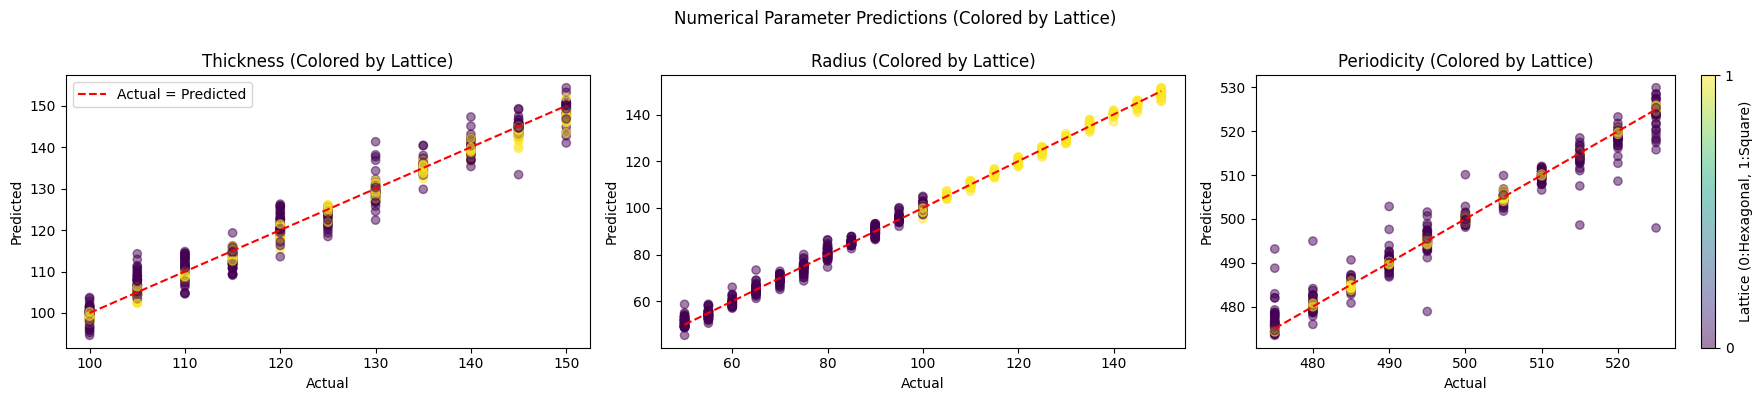

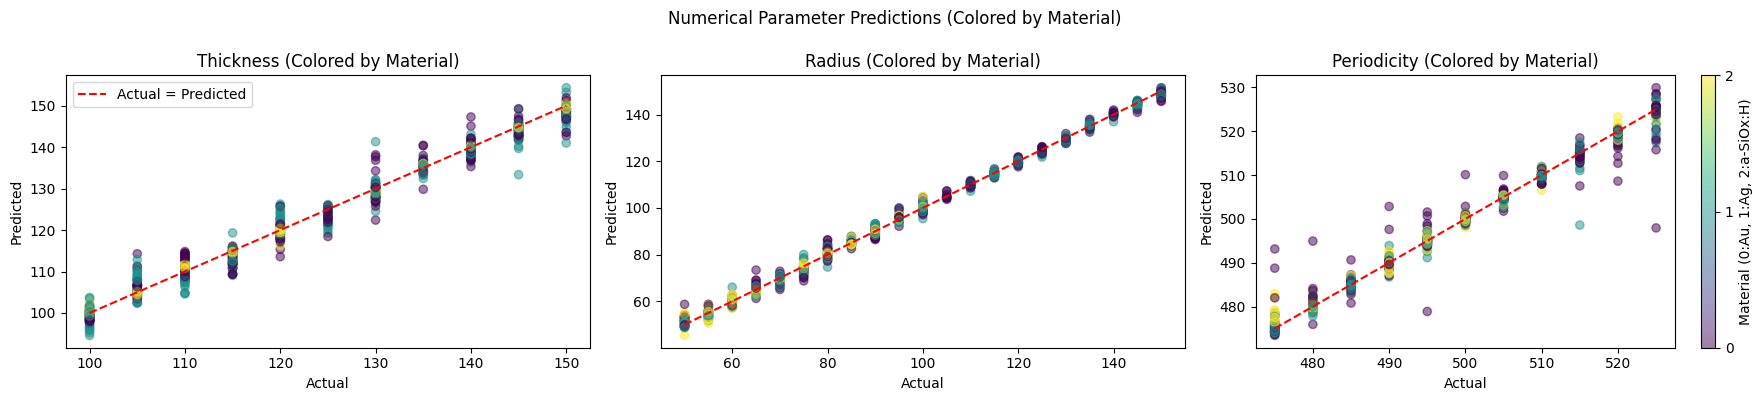

In [206]:
# --- Step 6: Plot Results ---

# Plotting numerical results colored by Lattice
plt.figure(figsize=(18, 4)) # Increased figure width to accommodate colorbar
for i, col in enumerate(['Thickness', 'Radius', 'Periodicity']):
    plt.subplot(1, 3, i+1)
    scatter = plt.scatter(y_test_final[col], y_pred_final[col], c=y_test_final['Lattice'], cmap='viridis', alpha=0.5)
    plt.plot([y_test_final[col].min(), y_test_final[col].max()],
             [y_test_final[col].min(), y_test_final[col].max()], 'r--', label='Actual = Predicted') # Added label here
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{col} (Colored by Lattice)")
    if i == 0: # Add legend to the first subplot of this figure
        plt.legend()

# Add colorbar for Lattice
plt.colorbar(scatter, ticks=[0, 1], label='Lattice (0:Hexagonal, 1:Square)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap with suptitle
plt.suptitle("Numerical Parameter Predictions (Colored by Lattice)", y=1.02)
plt.savefig('numerical_predictions_lattice.png') # Save the figure
plt.show()

# Plotting numerical results colored by Material
plt.figure(figsize=(18, 4)) # Increased figure width to accommodate colorbar
for i, col in enumerate(['Thickness', 'Radius', 'Periodicity']):
    plt.subplot(1, 3, i+1)
    scatter = plt.scatter(y_test_final[col], y_pred_final[col], c=y_test_final['Material'], cmap='viridis', alpha=0.5)
    plt.plot([y_test_final[col].min(), y_test_final[col].max()],
             [y_test_final[col].min(), y_test_final[col].max()], 'r--', label='Actual = Predicted') # Added label here
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{col} (Colored by Material)")
    if i == 0: # Add legend to the first subplot of this figure
        plt.legend()

# Add colorbar for Material
plt.colorbar(scatter, ticks=[0, 1, 2], label='Material (0:Au, 1:Ag, 2:a-SiOx:H)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap with suptitle
plt.suptitle("Numerical Parameter Predictions (Colored by Material)", y=1.02)
plt.savefig('numerical_predictions_material.png') # Save the figure
plt.show()

In [207]:
# --- Step 7: Display Sample Results ---
print("\nSample Predictions vs Actual Parameters:\n")
# print(pd.concat([
#     y_test_final.reset_index(drop=True).add_prefix("Actual_"),
#     y_pred_final.reset_index(drop=True).add_prefix("Pred_")
# ], axis=1).head(10))
display(pd.concat([
    y_test_final.reset_index(drop=True).add_prefix("Actual_"),
    y_pred_final.reset_index(drop=True).add_prefix("Pred_")
], axis=1).head(10))


Sample Predictions vs Actual Parameters:



,Actual_Thickness,Actual_Radius,Actual_Periodicity,Actual_Lattice,Actual_Material,Pred_Thickness,Pred_Radius,Pred_Periodicity,Pred_Lattice,Pred_Material
0,115.0,85.0,490.0,0,2,114.832726,86.028870,491.014465,0,2
1,145.0,90.0,500.0,0,0,146.772156,91.996933,500.521942,0,0
2,145.0,100.0,490.0,0,0,144.714462,100.570557,489.242035,0,0
3,145.0,125.0,495.0,1,0,142.514069,123.477631,494.721771,1,0
4,110.0,130.0,475.0,1,0,111.798912,130.450409,474.966980,1,0
5,100.0,60.0,525.0,0,2,100.162003,59.363243,521.850403,0,2
6,150.0,50.0,520.0,0,2,149.754181,51.862255,523.279358,0,2
7,115.0,100.0,525.0,0,2,114.555740,100.380638,525.065247,0,2
8,140.0,150.0,495.0,1,1,136.433014,147.498566,494.336823,1,1
9,125.0,150.0,490.0,1,1,125.342873,151.481918,489.807800,1,1


In [ ]:
def predict_parameters_from_spectrum():
    print("\nReady to predict parameters from a spectrum!")
    spectrum_input = input("Paste 200 comma-separated spectral values (normalized between 0-1):\n")

    try:
        spectrum_array = np.array([float(x.strip()) for x in spectrum_input.split(",")])
    except:
        print("Invalid input format.")
        return

    if spectrum_array.shape[0] != 200:
        print("\nError: Spectrum must have exactly 200 points.")
        return

    # Scale input spectrum
    spectrum_scaled = X_scaler.transform(spectrum_array.reshape(1, -1))

    # Predict using CVAE
    pred_output, _, _ = cvae.predict(spectrum_scaled)

    # Extract and inverse-transform numerical parameters
    pred_num = num_scaler.inverse_transform(pred_output[:, :3])[0]
    predicted_thickness, predicted_radius, predicted_periodicity = pred_num

    # Extract predicted categorical part (probabilities)
    pred_cat_probs = pred_output[:, 3:]
    predicted_lattice = np.argmax(pred_cat_probs[:, :2], axis=1)[0]
    predicted_material = np.argmax(pred_cat_probs[:, 2:], axis=1)[0]

    print(f"\nPredicted Thickness: {predicted_thickness:} nm")
    print(f"Predicted Radius: {predicted_radius:} nm")
    print(f"Predicted Periodicity: {predicted_periodicity:} nm")
    print(f"Predicted Material (0:Au, 1:Ag, 2:a-SiOx:H): {predicted_material}")
    print(f"Predicted Lattice (0:Hexagonal, 1:Square): {predicted_lattice}")

    # Ask user which material to filter on
    material_choice = input("\nFilter results by material:\n0: Au\n1: Ag\n2: a-SiOx:H\nEnter choice (or press Enter to skip): ")

    try:
        material_choice = int(material_choice)
    except:
        material_choice = None

    # Match tolerance
    tolerance = 10.0

    # Matching logic
    matches = data[
        (np.abs(data['Thickness'] - predicted_thickness) <= tolerance) &
        (np.abs(data['Radius'] - predicted_radius) <= tolerance) &
        (np.abs(data['Periodicity'] - predicted_periodicity) <= tolerance)
    ]

    if material_choice is not None:
        matches = matches[matches['Material'] == material_choice]

    if matches.empty:
        print("\n❌ No matching samples found.")
    else:
        print(f"\n✅ Found {len(matches)} matching samples:")
        print(matches[['Lattice', 'Material', 'Thickness', 'Radius', 'Periodicity']].head(5))

    # Run the prediction function
predict_parameters_from_spectrum()



Ready to predict parameters from a spectrum!
Paste 200 comma-separated spectral values (normalized between 0-1):
0.000664434,0.000689679,0.000721077,0.000747057,0.000761171,0.000767893,0.000778873,0.000802779,0.000837606,0.000872272,0.000896269,0.000908992,0.000920511,0.00094293,0.000979766,0.00102267,0.00105858,0.00108116,0.00109664,0.00111868,0.00115653,0.00120679,0.0012561,0.00129272,0.00131699,0.0013415,0.00138041,0.00143707,0.00150075,0.00155573,0.00159508,0.00162722,0.00166916,0.00173191,0.00181065,0.00188843,0.00195077,0.00199873,0.00204879,0.00211921,0.00221415,0.00231952,0.00241473,0.00249076,0.00255899,0.00264256,0.00275686,0.00289587,0.00303657,0.0031586,0.0032628,0.00337231,0.0035141,0.00369601,0.00389912,0.00409318,0.00426307,0.004424,0.00461126,0.00485161,0.00514003,0.00544238,0.00572382,0.00598022,0.00624546,0.00656614,0.00696288,0.00741033,0.0078549,0.0082582,0.00863093,0.00902706,0.00949906,0.0100485,0.0106134,0.0111072,0.0114805,0.0117574,0.0120112,0.0122962,0.012587

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



Predicted Thickness: 150.1048583984375 nm
Predicted Radius: 111.19231414794922 nm
Predicted Periodicity: 489.77154541015625 nm
Predicted Material (0:Au, 1:Ag, 2:a-SiOx:H): 1
Predicted Lattice (0:Hexagonal, 1:Square): 1

Filter results by material:
0: Au
1: Ag
2: a-SiOx:H
Enter choice (or press Enter to skip): 1

✅ Found 32 matching samples:
      Lattice  Material  Thickness  Radius  Periodicity
6425        1         1        145     105          480
6426        1         1        145     105          485
6427        1         1        145     105          490
6428        1         1        145     105          495
6436        1         1        145     110          480


In [208]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# true and predicted: shape (N, 3) for numerical parameters
mae = mean_absolute_error(y_test_num, y_pred_num)
rmse = np.sqrt(mean_squared_error(y_test_num, y_pred_num))

print(f"MAE: {mae:.2f} nm")
print(f"RMSE: {rmse:.2f} nm")

MAE: 1.41 nm
RMSE: 2.25 nm


In [209]:
for i, feature in enumerate(["Thickness", "Radius", "Periodicity"]):
    mae = mean_absolute_error(y_test_num[:, i], y_pred_num[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_num[:, i], y_pred_num[:, i]))
    print(f"{feature} → MAE: {mae:.2f} nm, RMSE: {rmse:.2f} nm")

Thickness → MAE: 1.71 nm, RMSE: 2.41 nm
Radius → MAE: 1.32 nm, RMSE: 1.78 nm
Periodicity → MAE: 1.21 nm, RMSE: 2.50 nm


In [ ]:
from sklearn.metrics import r2_score

# y_test_num = true values
# y_pred_num = predicted values

# Calculate R² for each feature
features = ["Thickness", "Radius", "Periodicity"]
for i, feature in enumerate(features):
    r2 = r2_score(y_test_num[:, i], y_pred_num[:, i])
    print(f"R² ({feature}): {r2:.4f}")

R² (Thickness): 0.9772
R² (Radius): 0.9965
R² (Periodicity): 0.9743


In [ ]:
from sklearn.metrics import accuracy_score

lattice_acc = accuracy_score(y_test_cat[:, 0], y_pred_cat[:, 0])
material_acc = accuracy_score(y_test_cat[:, 1], y_pred_cat[:, 1])

print(f"Lattice Accuracy: {lattice_acc:.2%}")
print(f"Material Accuracy: {material_acc:.2%}")

Lattice Accuracy: 100.00%
Material Accuracy: 100.00%


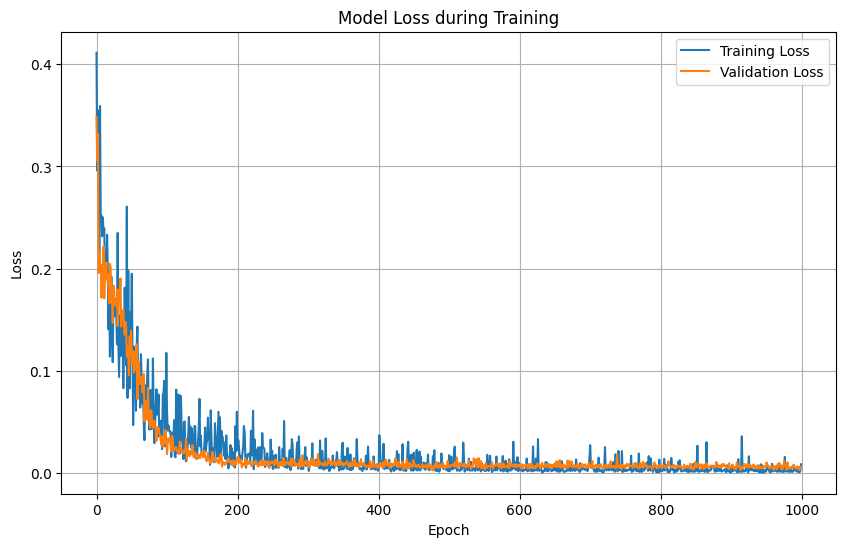

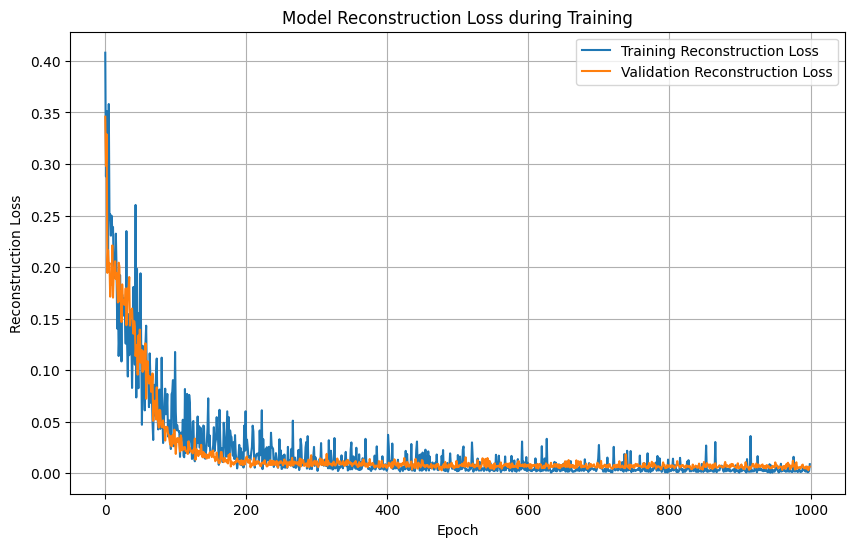

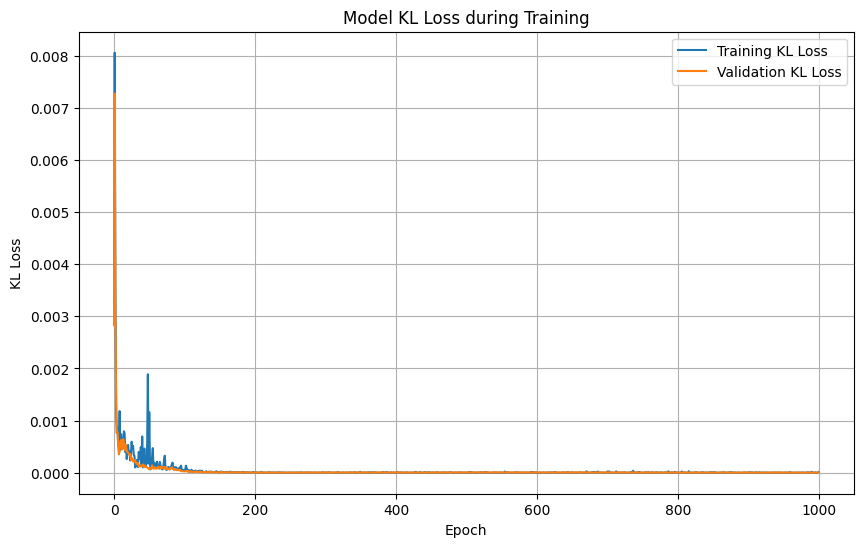

In [211]:
import matplotlib.pyplot as plt

# Plot training & validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('model_loss_plot.png') # Save the total loss plot
plt.show()


# You can also plot individual loss components if available in history
if 'reconstruction_loss' in history.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['reconstruction_loss'], label='Training Reconstruction Loss')
    plt.plot(history.history['val_reconstruction_loss'], label='Validation Reconstruction Loss')
    plt.title('Model Reconstruction Loss during Training')
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('reconstruction_loss_plot.png') # Save the reconstruction loss plot
    plt.show()


if 'kl_loss' in history.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['kl_loss'], label='Training KL Loss')
    plt.plot(history.history['val_kl_loss'], label='Validation KL Loss')
    plt.title('Model KL Loss during Training')
    plt.xlabel('Epoch')
    plt.ylabel('KL Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('kl_loss_plot.png') # Save the KL loss plot
    plt.show()

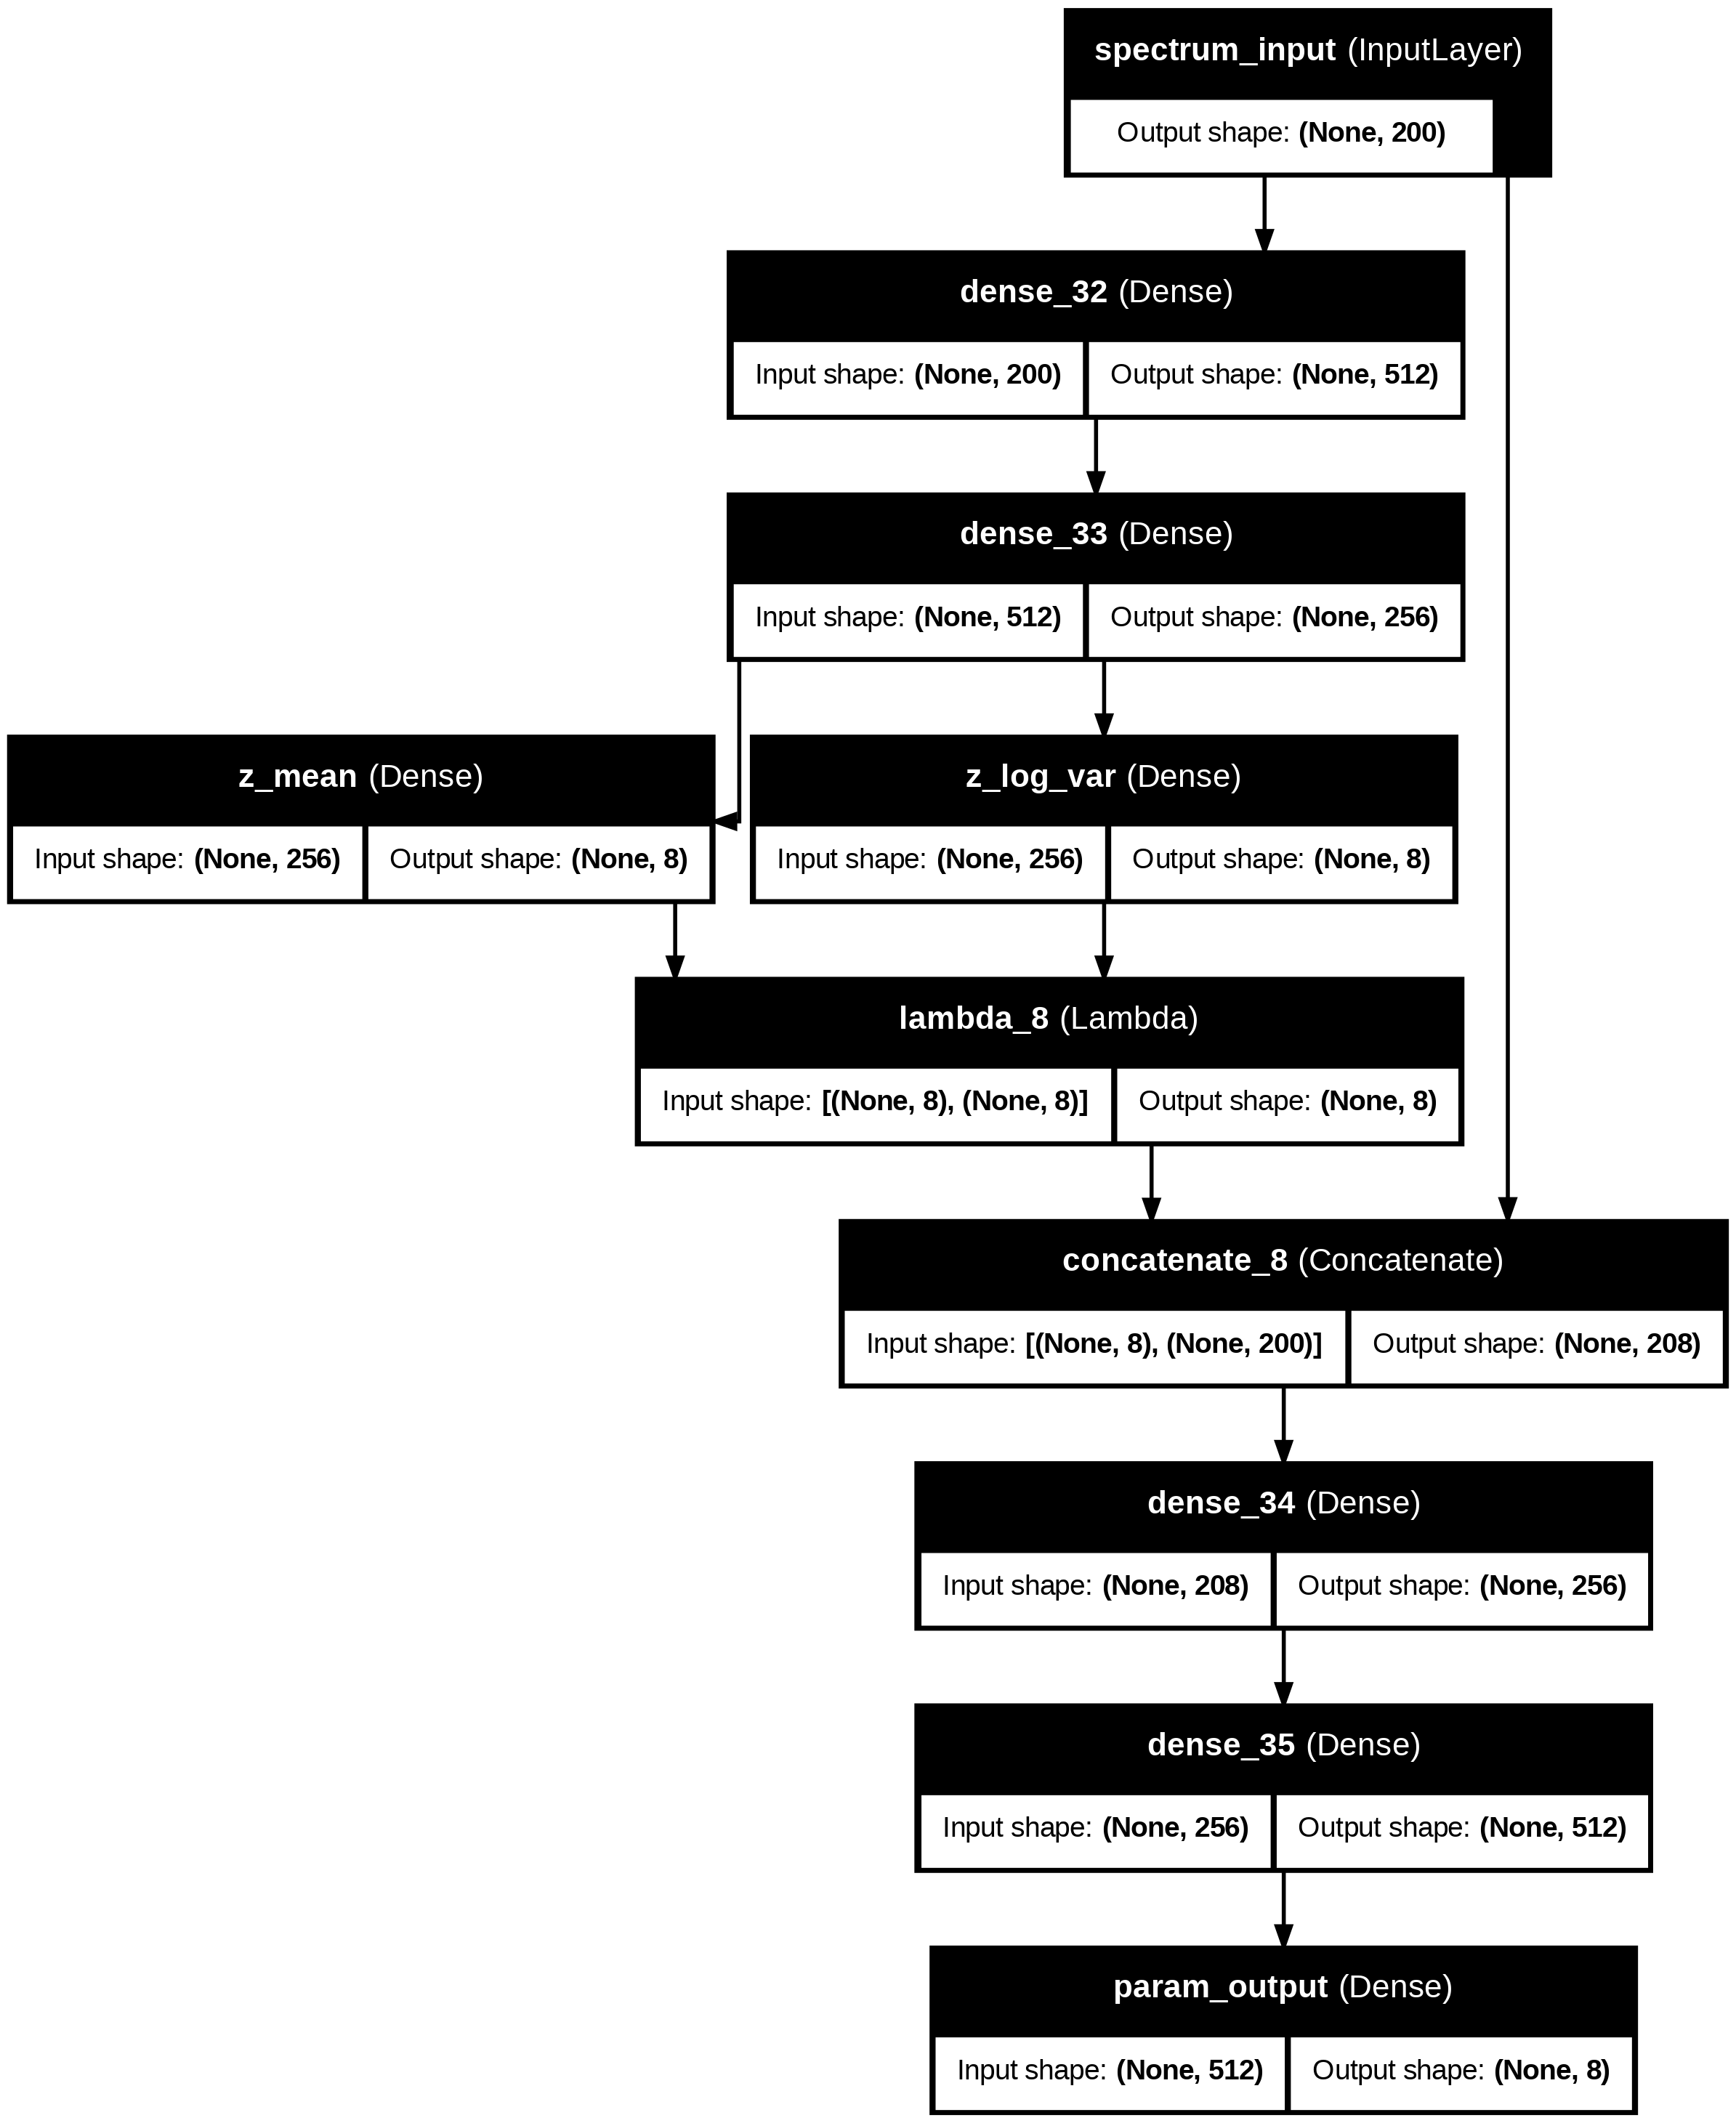

In [212]:
tf.keras.utils.plot_model(cvae, show_shapes=True, show_layer_names=True, to_file='cvae_model_plot.png')

from IPython.display import Image
Image('cvae_model_plot.png')